In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")

# just checking what we have
print(merged.shape)
merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 'PERIGEE', 'APOGEE']].head(10)

(66666, 55)


,OBJECT_NAME,OBJECT_TYPE,altitude_km,PERIGEE,APOGEE
0,OPS 3674 (VELA 4),PAYLOAD,110631.921857,42502.0,163507
1,YZ-1 R/B,ROCKET BODY,71550.191715,25492.0,159470
2,ASTRON,PAYLOAD,161495.854880,32806.0,171431
3,OPS 3662 (VELA 3),PAYLOAD,157847.293602,49971.0,156567
4,CXO,PAYLOAD,130845.955703,9371.0,139458
5,SL-12 R/B(2),ROCKET BODY,166611.346992,30569.0,171120
6,SOLRAD 11A/B AKM,ROCKET BODY,122190.544513,118863.0,126618
7,TITAN 3C TRANSTAGE R/B,ROCKET BODY,117024.710806,14995.0,117656
8,TITAN 3C TRANSTAGE R/B,ROCKET BODY,118453.039527,7473.0,121163
9,SOLRAD 11A,PAYLOAD,117718.082878,117622.0,119338


In [10]:
# some constants i need
MU = 398600  # earth's gravitational parameter (km3/s2)
R_EARTH = 6371  # earth radius in km

# basically delta-v is how much velocity change is needed
# to drop perigee to 200km so atmosphere drags it down naturally
# using hohmann transfer — most fuel efficient orbital maneuver

def calc_deltav(altitude_km):
    if pd.isna(altitude_km) or altitude_km < 200:
        return np.nan
    
    r1 = R_EARTH + altitude_km  # current orbit radius
    r_perigee = R_EARTH + 200   # target perigee (atm drag takes over here)
    
    # velocity in current circular orbit
    v_circular = np.sqrt(MU / r1)
    
    # velocity at apogee of transfer ellipse
    v_transfer = np.sqrt(MU * (2/r1 - 2/(r1 + r_perigee)))
    
    dv = v_circular - v_transfer
    return round(abs(dv), 4)

merged['deltav_km_s'] = merged['altitude_km'].apply(calc_deltav)

print("delta-v calculated for", merged['deltav_km_s'].notna().sum(), "objects")
merged[['OBJECT_NAME', 'altitude_km', 'deltav_km_s']].dropna().head(10)

delta-v calculated for 37743 objects


,OBJECT_NAME,altitude_km,deltav_km_s
0,OPS 3674 (VELA 4),110631.921857,1.2438
1,YZ-1 R/B,71550.191715,1.3697
2,ASTRON,161495.854880,1.1180
3,OPS 3662 (VELA 3),157847.293602,1.1258
4,CXO,130845.955703,1.1891
5,SL-12 R/B(2),166611.346992,1.1073
6,SOLRAD 11A/B AKM,122190.544513,1.2117
7,TITAN 3C TRANSTAGE R/B,117024.710806,1.2258
8,TITAN 3C TRANSTAGE R/B,118453.039527,1.2218
9,SOLRAD 11A,117718.082878,1.2239


In [11]:
# higher altitude = more delta-v needed to deorbit
# makes sense physically — more energy to get down from higher up

print(merged[['altitude_km', 'deltav_km_s']].dropna().describe())
print("\nhardest objects to deorbit:")
merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 'deltav_km_s']].dropna().sort_values('deltav_km_s', ascending=False).head(10)

        altitude_km   deltav_km_s
count  3.774300e+04  37743.000000
mean   1.123860e+31      0.318713
std    1.496418e+33      0.446449
min    2.002838e+02      0.000000
25%    4.926207e+02      0.082300
50%    7.631169e+02      0.141100
75%    1.387084e+03      0.259800
max    2.618853e+35      1.480200

hardest objects to deorbit:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,deltav_km_s
43773,CZ-3C DEB,DEBRIS,32556.092025,1.4802
27458,CZ-3C DEB,DEBRIS,31994.500485,1.4802
35121,ATLAS 5 CENTAUR DEB,DEBRIS,32087.701355,1.4802
26218,ARIANE 5 R/B,ROCKET BODY,32451.256786,1.4802
28434,COSMOS 1903,PAYLOAD,32008.822114,1.4802
36066,ATLAS 5 CENTAUR DEB,DEBRIS,32356.828256,1.4802
20569,ATLAS 5 CENTAUR DEB,DEBRIS,32154.999749,1.4802
26057,ATLAS 5 CENTAUR DEB,DEBRIS,32286.776765,1.4802
28581,ATLAS 5 CENTAUR DEB,DEBRIS,32153.944056,1.4802
42437,TDO 2 SPACECRAFT,PAYLOAD,32089.332520,1.4802


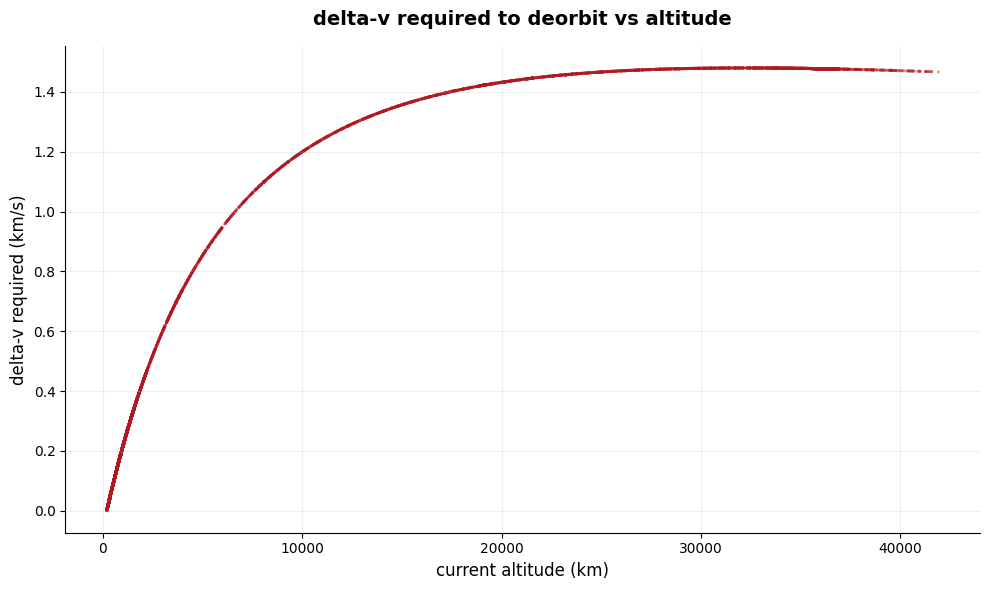

In [17]:
# delta-v vs altitude — should show a clear curve
fig, ax = plt.subplots(figsize=(10, 6))

sample = merged[merged['altitude_km'].between(200, 42000)].dropna(subset=['deltav_km_s'])

ax.scatter(sample['altitude_km'], sample['deltav_km_s'],
           c="#b01921", s=5, alpha=0.4, edgecolors='none')

ax.set_title('delta-v required to deorbit vs altitude', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('current altitude (km)', fontsize=12)
ax.set_ylabel('delta-v required (km/s)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8963/2914479435.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_dv = merged.groupby('regime')['deltav_km_s'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()


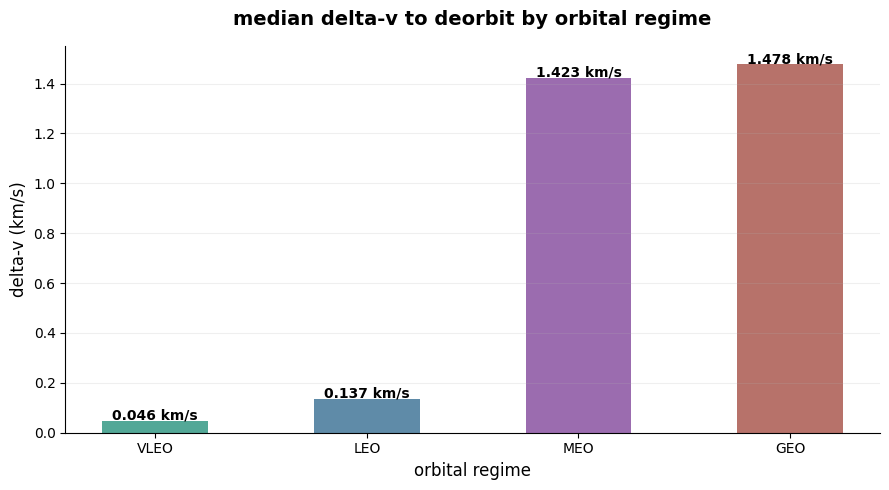

In [18]:
# delta-v by orbital regime — how hard is each regime to clean up
fig, ax = plt.subplots(figsize=(9, 5))

regime_dv = merged.groupby('regime')['deltav_km_s'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()
colors = ["#53a897", "#5f8ba8", "#9b6caf", "#b7726a"]

bars = ax.bar(regime_dv.index, regime_dv.values, color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, regime_dv.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f} km/s', ha='center', fontweight='bold', fontsize=10)

ax.set_title('median delta-v to deorbit by orbital regime', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('orbital regime', fontsize=12)
ax.set_ylabel('delta-v (km/s)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [14]:
# most critical objects — high risk AND hard to deorbit
# these are the ones we should prioritize

merged['deorbit_priority'] = merged['deltav_km_s'] * merged['altitude_km'] / 1000

priority_list = merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 
                          'deltav_km_s', 'risk_label']].dropna().sort_values('deltav_km_s', ascending=False)

print("top 15 hardest objects to deorbit:")
priority_list.head(15)

top 15 hardest objects to deorbit:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,deltav_km_s,risk_label
43773,CZ-3C DEB,DEBRIS,32556.092025,1.4802,LOW
27458,CZ-3C DEB,DEBRIS,31994.500485,1.4802,LOW
35121,ATLAS 5 CENTAUR DEB,DEBRIS,32087.701355,1.4802,LOW
26218,ARIANE 5 R/B,ROCKET BODY,32451.256786,1.4802,HIGH
28434,COSMOS 1903,PAYLOAD,32008.822114,1.4802,LOW
36066,ATLAS 5 CENTAUR DEB,DEBRIS,32356.828256,1.4802,LOW
20569,ATLAS 5 CENTAUR DEB,DEBRIS,32154.999749,1.4802,LOW
26057,ATLAS 5 CENTAUR DEB,DEBRIS,32286.776765,1.4802,LOW
28581,ATLAS 5 CENTAUR DEB,DEBRIS,32153.944056,1.4802,LOW
42437,TDO 2 SPACECRAFT,PAYLOAD,32089.332520,1.4802,LOW


In [15]:
merged.to_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet", index=False)
print("saved with delta-v!!", merged.shape)

saved with delta-v!! (66666, 57)
